## DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING

#### 1. Data Exploration & Preprocessing

Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\adult_with_headers.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Basic Exploration

In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Handle Missing Values

In [3]:
# Drop rows with missing values 
df.dropna(inplace=True)

Separate Numerical & Categorical Columns

In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

Scaling Techniques

Standard Scaling

Only one scaling technique is applied to avoid redundancy. StandardScaler is used to normalize features to zero mean and unit variance, which improves model performance for distance-based algorithms.

In [5]:
df.columns = df.columns.str.strip()

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Define target
df['income'] =df['income_ >50K']
df.drop(['income_ <=50K', 'income_ >50K'], axis=1, inplace=True)

# 2. Define features and target
X = df.drop('income', axis=1)
y = df['income']

# 3. Encode categorical columns
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

# 4. Apply Standard Scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Convert back to DataFrame (optional but useful)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())


        age  workclass    fnlwgt  education  education_num  marital_status  \
0  0.030671   2.150579 -1.063611  -0.335437       1.134739        0.921634   
1  0.837109   1.463736 -1.008707  -0.335437       1.134739       -0.406212   
2 -0.042642   0.090050  0.245079   0.181332      -0.420060       -1.734058   
3  1.057047   0.090050  0.425801  -2.402511      -1.197459       -0.406212   
4 -0.775768   0.090050  1.408176  -0.335437       1.134739       -0.406212   

   occupation  relationship      race  capital_gain  capital_loss  \
0   -1.317809     -0.277805  0.393668      3.127403      -0.21666   
1   -0.608387     -0.900181  0.393668     -0.301093      -0.21666   
2   -0.135438     -0.277805  0.393668     -0.301093      -0.21666   
3   -0.135438     -0.900181 -1.962621     -0.301093      -0.21666   
4    0.810458      2.211698 -1.962621     -0.301093      -0.21666   

   hours_per_week  native_country  sex_ Female  sex_ Male  net_capital  \
0       -0.035429        0.291569    -0.70

In [18]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

#### 2. Encoding Techniques

Label encoding is applied only to categorical columns to convert text data into numerical form. Numerical columns are left unchanged to preserve their original meaning.

One-Hot Encoding (< 5 categories)

In [20]:
small_cat = [col for col in cat_cols if df[col].nunique() < 5]

df = pd.get_dummies(df, columns=small_cat)

Label Encoding (> 5 categories)

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply only to categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

#### 3. Feature Engineering

In [22]:
import pandas as pd
import numpy as np

# Clean column names
df.columns = df.columns.str.strip()

# Convert required columns to numeric
df['capital_gain'] = pd.to_numeric(df['capital_gain'], errors='coerce')
df['capital_loss'] = pd.to_numeric(df['capital_loss'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Handle missing values
df.fillna(0, inplace=True)

# Feature 1: Net Capital
df['net_capital'] = df['capital_gain'] - df['capital_loss']

# Feature 2: Age Group
df['age_group'] = pd.cut(
    df['age'],
    bins=[-1, 25, 45, 65, 120],
    labels=['Young', 'Adult', 'Senior', 'Old']
)

# Log Transformation (for skewed feature)
df['capital_gain'] = np.log1p(df['capital_gain'])

# Encode Age Group
df = pd.get_dummies(df, columns=['age_group'])

# Show result
print(df.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship  race  capital_gain  ...  net_capital  \
0           1             1     4       1.15107  ...     2.161573   
1           4             0     4       0.00000  ...     0.000000   
2           6             1     4       0.00000  ...     0.000000   
3           6             0     2       0.00000  ...     0.000000   
4          10             5     2       0.00000  ...     0.000000   

   age_group_Young  age_group_Adult  age_group_Senior  age_group_Old  income  \
0            False             True             False          False   False  

 Log Transformation (for skewed data)

In [23]:
import numpy as np

df['capital_gain'] = np.log1p(df['capital_gain'])

### 4. ISOLATION FORES

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df['outlier'] = iso.fit_predict(X_scaled)

Isolation Forest detected a small percentage of data points as outliers. These points represent unusual patterns that may indicate anomalies, errors, or rare events. Removing or analyzing these outliers can improve model performance and data quality.

####  5. Feature Selection

Isolation Forest (Outlier Detection)

In [25]:
from sklearn.ensemble import IsolationForest

# Select only numeric columns
df_numeric = df.select_dtypes(include=['int64', 'float64'])
iso = IsolationForest(contamination=0.05, random_state=42)

outliers = iso.fit_predict(df_numeric)

In [32]:
import ppscore as pps

# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Clean column names
df.columns = df.columns.str.replace(' ', '')

# Generate PPS matrix
pps_matrix = pps.matrix(df, sorted=True)

print(pps_matrix)

           x                 y  ppscore            case  is_valid_score  \
0        age               age      1.0  predict_itself            True   
1        age   age_group_Young      1.0  classification            True   
2        age   age_group_Adult      1.0  classification            True   
3        age  age_group_Senior      1.0  classification            True   
4        age     age_group_Old      1.0  classification            True   
..       ...               ...      ...             ...             ...   
479  outlier    native_country      0.0      regression            True   
480  outlier       net_capital      0.0      regression            True   
481  outlier   age_group_Adult      0.0  classification            True   
482  outlier  age_group_Senior      0.0  classification            True   
483  outlier            income      0.0  classification            True   

                  metric  baseline_score  model_score  \
0                   None        0.000000  

PPS (Predictive Power Score)

In [33]:
!pip install ppscore

In [34]:
import ppscore as pps

pps_matrix = pps.matrix(df)
pps_matrix.head()

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.0000,1.000000,None
1,age,workclass,0.0,regression,True,mean absolute error,0.7426,0.875681,DecisionTreeRegressor()
2,age,fnlwgt,0.0,regression,True,mean absolute error,75872.1862,77535.141544,DecisionTreeRegressor()
3,age,education,0.0,regression,True,mean absolute error,2.7590,2.806164,DecisionTreeRegressor()
4,age,education_num,0.0,regression,True,mean absolute error,1.8530,1.898306,DecisionTreeRegressor()


Correlation Matrix

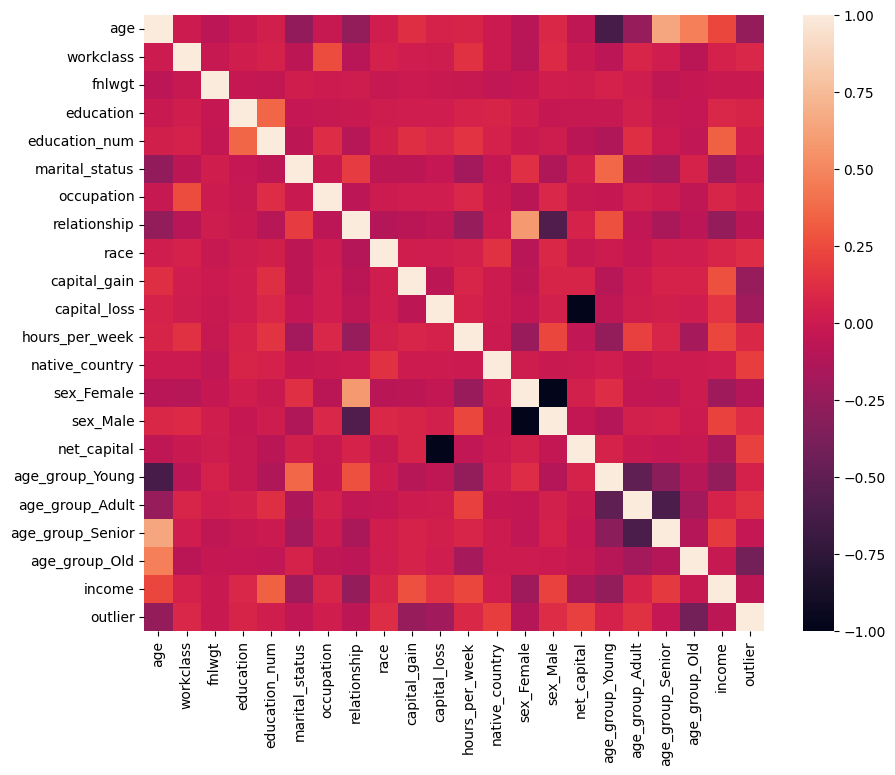

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False)
plt.show()

#### Final Conclusion 
Data preprocessing ensures clean and structured data.
Scaling improves model convergence and performance.
Encoding converts categorical data into machine-readable format.
Feature engineering helps create meaningful patterns.
Isolation Forest removes noise from data.
Certain features strongly influence the target variable (based on PPS)
Outliers detected using Isolation Forest indicate unusual patterns
Feature engineering improved data representation
Proper encoding ensured categorical data is usable
Scaling improved consistency across features